In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read your dataframe (replace path with your file if needed)
df = pd.read_csv("/Users/annasve/Desktop/article_data/output/expression_overall/bgc_expression_per_strain_both.csv")

In [2]:
df

,Strain,Total_BGCs,BGCs_expressed_75th,Not_expressed_75th,BGCs_expressed_50th,Not_expressed_50th
0,NBC_01734,15,4,11,7,8
1,NBC_01392,20,5,15,9,11
2,NBC_01530,33,13,20,18,15
3,NBC_00028,27,15,12,19,8
4,NBC_00222,41,15,26,24,17
...,...,...,...,...,...,...
127,NBC_00454,21,8,13,12,9
128,NBC_01518,32,9,23,23,9
129,NBC_01520,26,11,15,16,10
130,NBC_00439,30,13,17,18,12


In [3]:
# Compute percentages
df["Pct_expressed_75th"] = 100 * df["BGCs_expressed_75th"] / df["Total_BGCs"]
df["Pct_expressed_50th"] = 100 * df["BGCs_expressed_50th"] / df["Total_BGCs"]

df["Pct_not_expressed_75th"] = 100 - df["Pct_expressed_75th"]
df["Pct_not_expressed_50th"] = 100 - df["Pct_expressed_50th"]

In [4]:
# Percentages per strain
df["Pct_expressed_75th"] = 100 * df["BGCs_expressed_75th"] / df["Total_BGCs"]
df["Pct_expressed_50th"] = 100 * df["BGCs_expressed_50th"] / df["Total_BGCs"]

# Helper for summary stats
def summarize(series: pd.Series):
    s = series.dropna()
    q1, med, q3 = np.percentile(s, [25,50,75])
    return pd.Series({
        "mean": s.mean(),
        "median": med,
        "q1": q1,
        "q3": q3,
        "IQR": q3 - q1,
        "min": s.min(),
        "max": s.max(),
        "std": s.std(ddof=1),
        "n_strains": s.size
    })

sum75 = summarize(df["Pct_expressed_75th"])
sum50 = summarize(df["Pct_expressed_50th"])

# Weighted means by BGC counts (more representative of genome-level activity)
wmean75 = np.average(df["Pct_expressed_75th"], weights=df["Total_BGCs"])
wmean50 = np.average(df["Pct_expressed_50th"], weights=df["Total_BGCs"])

# How many strains exceed certain benchmarks
n_over50_75 = (df["Pct_expressed_75th"] >= 50).sum()
n_over50_50 = (df["Pct_expressed_50th"] >= 50).sum()

# Correlation between thresholds (consistency of ranking)
corr = df["Pct_expressed_75th"].corr(df["Pct_expressed_50th"])

# Optional: save a neat summary table
summary = pd.DataFrame({
    "metric": ["mean","median","q1","q3","IQR","min","max","std","n_strains","weighted_mean","n_strains_≥50pct"],
    "75th": [sum75["mean"], sum75["median"], sum75["q1"], sum75["q3"], sum75["IQR"], sum75["min"], sum75["max"], sum75["std"], sum75["n_strains"], wmean75, n_over50_75],
    "50th": [sum50["mean"], sum50["median"], sum50["q1"], sum50["q3"], sum50["IQR"], sum50["min"], sum50["max"], sum50["std"], sum50["n_strains"], wmean50, n_over50_50],
}).set_index("metric")

print(summary.round(2))
print(f"\nPearson r (75th vs 50th) = {corr:.2f}")


                    75th    50th
metric                          
mean               43.67   63.03
median             43.53   62.68
q1                 36.78   57.14
q3                 50.00   69.87
IQR                13.22   12.72
min                19.23   26.92
max                70.00   95.00
std                 9.62   10.23
n_strains         132.00  132.00
weighted_mean      43.25   62.78
n_strains_≥50pct   37.00  120.00

Pearson r (75th vs 50th) = 0.70


In [5]:
df

,Strain,Total_BGCs,BGCs_expressed_75th,Not_expressed_75th,BGCs_expressed_50th,Not_expressed_50th,Pct_expressed_75th,Pct_expressed_50th,Pct_not_expressed_75th,Pct_not_expressed_50th
0,NBC_01734,15,4,11,7,8,26.666667,46.666667,73.333333,53.333333
1,NBC_01392,20,5,15,9,11,25.000000,45.000000,75.000000,55.000000
2,NBC_01530,33,13,20,18,15,39.393939,54.545455,60.606061,45.454545
3,NBC_00028,27,15,12,19,8,55.555556,70.370370,44.444444,29.629630
4,NBC_00222,41,15,26,24,17,36.585366,58.536585,63.414634,41.463415
...,...,...,...,...,...,...,...,...,...,...
127,NBC_00454,21,8,13,12,9,38.095238,57.142857,61.904762,42.857143
128,NBC_01518,32,9,23,23,9,28.125000,71.875000,71.875000,28.125000
129,NBC_01520,26,11,15,16,10,42.307692,61.538462,57.692308,38.461538
130,NBC_00439,30,13,17,18,12,43.333333,60.000000,56.666667,40.000000


In [6]:
import pandas as pd

# If df already exists, skip loading. Otherwise:
# df = pd.read_csv("bgc_expression_summary.csv", sep="\t")

# Sanity checks (optional but helpful)
assert {"Strain","Total_BGCs","BGCs_expressed_75th","BGCs_expressed_50th"}.issubset(df.columns)

# Global totals across all strains
total_bgcs        = int(df["Total_BGCs"].sum())
total_expr_75     = int(df["BGCs_expressed_75th"].sum())
total_expr_50     = int(df["BGCs_expressed_50th"].sum())

# (Optional) recompute global “not expressed” from provided columns if present
total_not_75 = int(df["Not_expressed_75th"].sum()) if "Not_expressed_75th" in df.columns else total_bgcs - total_expr_75
total_not_50 = int(df["Not_expressed_50th"].sum()) if "Not_expressed_50th" in df.columns else total_bgcs - total_expr_50

# Fractions (global)
pct_expr_75 = 100 * total_expr_75 / total_bgcs if total_bgcs else float("nan")
pct_expr_50 = 100 * total_expr_50 / total_bgcs if total_bgcs else float("nan")

print(f"Total BGCs (all strains): {total_bgcs:,}")
print(f"Expressed @75th: {total_expr_75:,} ({pct_expr_75:.1f}%), Not expressed: {total_not_75:,}")
print(f"Expressed @50th: {total_expr_50:,} ({pct_expr_50:.1f}%), Not expressed: {total_not_50:,}")


Total BGCs (all strains): 3,993
Expressed @75th: 1,727 (43.3%), Not expressed: 2,266
Expressed @50th: 2,507 (62.8%), Not expressed: 1,486


/var/folders/zm/bd67fqqd1cg4ycfsvq5v2x_h0000gp/T/ipykernel_37298/3582112322.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # ↑ increase bottom margin


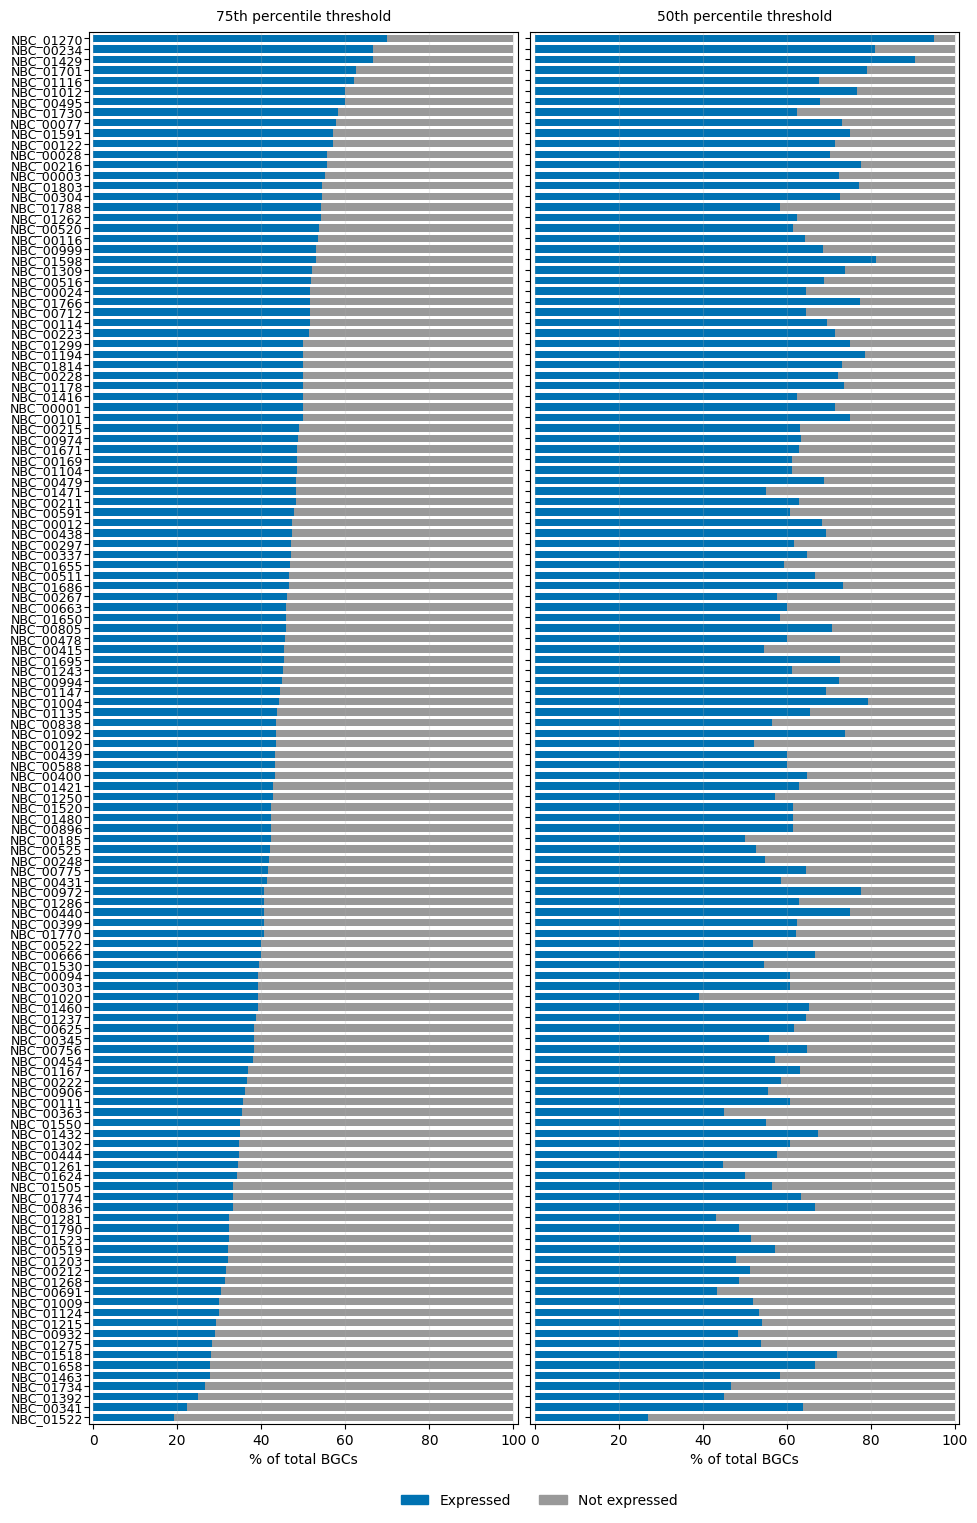

In [7]:
# Sort strains by 75th percentile
df_sorted = df.sort_values("Pct_expressed_75th", ascending=False).reset_index(drop=True)
strains = df_sorted["Strain"]

# Colors
expressed_color = "#0072B2"
not_expressed_color = "#999999"

# Create figure
fig, axes = plt.subplots(
    1, 2, figsize=(10, 16), sharey=True,
    gridspec_kw={'left': 0.05, 'right': 0.92, 'top': 0.93, 'bottom': 0.06, 'wspace': 0.03}
)

# Helper function to draw one panel
def draw_panel(ax, df_sub, exp_col, notexp_col, title):
    for _, row in df_sub.iterrows():
        ax.barh(row["Strain"], row[exp_col], color=expressed_color, height=0.7)
        ax.barh(row["Strain"], row[notexp_col], left=row[exp_col], color=not_expressed_color, height=0.7)

    ax.set_xlim(-1, 101)  # extend slightly beyond 0–100 to remove space
    ax.set_xlabel("% of total BGCs", fontsize=10)
    ax.set_title(title, fontsize=10, pad=8)
    ax.grid(alpha=0.25, axis="x")
    ax.tick_params(axis="y", labelsize=9, pad=1)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.margins(y=0.002)  # tight vertical spacing

# Draw left panel (75th percentile)
draw_panel(axes[0], df_sorted, "Pct_expressed_75th", "Pct_not_expressed_75th",
           "75th percentile threshold")
axes[0].invert_yaxis()

# Draw right panel (50th percentile)
df_sorted_50 = df.set_index("Strain").loc[strains].reset_index()
draw_panel(axes[1], df_sorted_50, "Pct_expressed_50th", "Pct_not_expressed_50th",
           "50th percentile threshold")

# ... everything else stays the same ...

# Legend at the bottom center (outside)
handles = [
    plt.Rectangle((0, 0), 1, 1, color=expressed_color),
    plt.Rectangle((0, 0), 1, 1, color=not_expressed_color)
]
fig.legend(
    handles, ["Expressed", "Not expressed"],
    loc="lower center", bbox_to_anchor=(0.5, -0.00001),  # center bottom, a bit below axes
    ncol=2, frameon=False, fontsize=10
)

# Adjust layout to leave room for the bottom legend
plt.tight_layout()  # ↑ increase bottom margin
plt.savefig("bgc_expression_tightbars_bottomlegend.png", dpi=400)
plt.show()

# 3) Save without clipping
fig.savefig(
    "bgc_expression_tightbars.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white"   # avoids weird cropping in some viewers
)


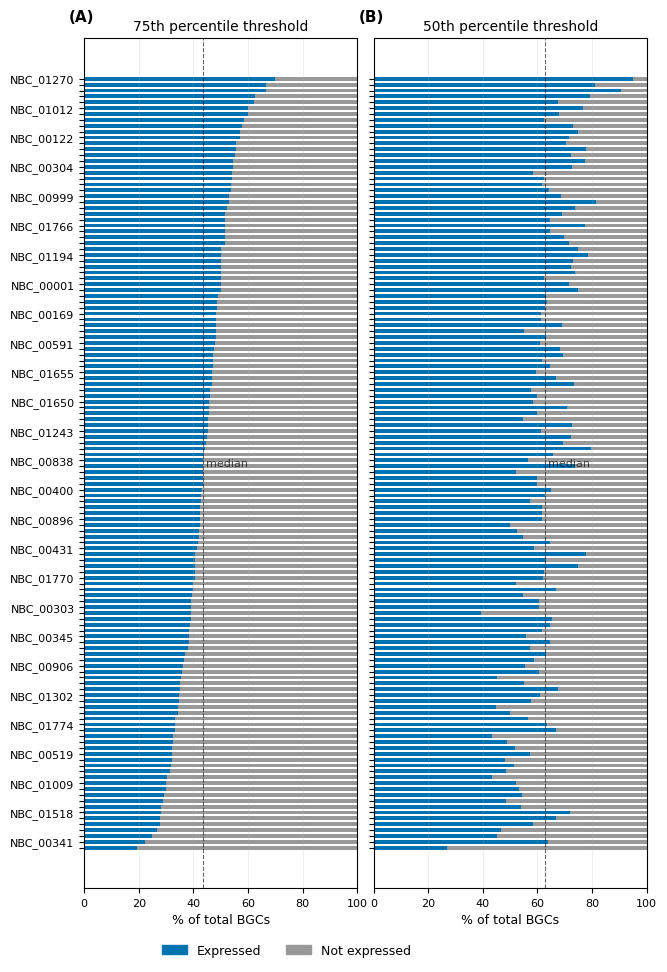

In [8]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8
})

expressed_color = "#0072B2"    # Okabe–Ito blue
not_expressed_color = "#999999"

# … build df_sorted and df_sorted_50 exactly as you already do …

fig, axes = plt.subplots(
    1, 2, figsize=(7.5, 10), sharey=True,
    gridspec_kw={"left":0.23, "right":0.98, "top":0.95, "bottom":0.10, "wspace":0.06}
)

def panel(ax, df_sub, exp_col, notexp_col, title, tag):
    for _, r in df_sub.iterrows():
        ax.barh(r["Strain"], r[exp_col], color=expressed_color, height=0.65)
        ax.barh(r["Strain"], r[notexp_col], left=r[exp_col], color=not_expressed_color, height=0.65)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of total BGCs")
    ax.set_title(title, pad=6)
    ax.grid(axis="x", alpha=0.2)
    # show every 5th y-tick to reduce clutter
    yticks = ax.get_yticks()
    labels = [l.get_text() for l in ax.get_yticklabels()]
    for i, lab in enumerate(ax.get_yticklabels()):
        lab.set_visible(i % 5 == 0)
    # median line
    med = df_sub[exp_col].median()
    ax.axvline(med, ls="--", lw=0.8, color="k", alpha=0.6)
    ax.text(med+1, 0.5, "median", transform=ax.get_xaxis_transform(),
            ha="left", va="center", fontsize=8, alpha=0.7)
    # panel tag
    ax.text(-0.055, 1.02, tag, transform=ax.transAxes, fontsize=11, fontweight="bold")

# left: 75th
axes[0].invert_yaxis()
panel(axes[0], df_sorted, "Pct_expressed_75th", "Pct_not_expressed_75th",
      "75th percentile threshold", "(A)")

# right: 50th (same order)
panel(axes[1], df.set_index("Strain").loc[df_sorted["Strain"]].reset_index(),
      "Pct_expressed_50th", "Pct_not_expressed_50th",
      "50th percentile threshold", "(B)")

# legend bottom-center, closer to plots
handles = [mpl.patches.Patch(color=expressed_color, label="Expressed"),
           mpl.patches.Patch(color=not_expressed_color, label="Not expressed")]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.02))

# save vector + raster
fig.savefig("bgc_expression_panels.pdf")                       # vector for manuscript
fig.savefig("bgc_expression_panels.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
